In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
from spk_feat_cluster_comp_analysis  import *

In [2]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

#### Compiling the master dataset

We load all per-cell cluster pickle files — one per (cell, spike feature) pair — and concatenate them into a single master DataFrame. Each row is one pairwise cluster comparison (e.g., Low vs. High for `peak_amp` in c1), carrying both recording metadata (patch type, cell type, cortical depth, dark neuron flag) and clustering quality metrics (nRMSE, cos_sim, num_clusters, temporal_rho). Everything downstream depends on this table.

In [3]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [4]:
df_master

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
0,c1,Juxta,IC,PC,843.9,False,False,peak_amp,3,Low-High,0.094347,0.992257,-0.792646,0.000000e+00,1.0
1,c1,Juxta,IC,PC,843.9,False,False,peak_sharpness,3,Low-High,0.085215,0.995814,-0.627883,1.313414e-187,1.0
2,c1,Juxta,IC,PC,843.9,False,False,exp_lambda,3,Low-High,0.053938,0.989929,-0.527016,1.731403e-122,1.0
3,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-Mid,0.043199,0.998375,0.317826,2.667009e-41,1.0
4,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-High,0.039899,0.997296,0.317826,2.667009e-41,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-High,0.057512,0.971113,0.398502,4.885509e-256,1.0
146,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Mid-High,0.044390,0.980010,0.398502,4.885509e-256,1.0
147,c45,Juxta,VC,PC,1137.0,False,True,log_isi,3,Low-High,0.020428,0.996051,-0.100840,9.668021e-17,1.0
148,c46,Juxta,VC,PC,1039.7,False,True,exp_lambda,2,Low-High,0.010027,0.999696,-0.056060,3.679477e-06,1.0


In [5]:
#sort by cell id
# Create a numeric column for sorting (c1, c2, c10, etc.)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)

# Sort by the numeric ID, then by feature name
df_master = df_master.sort_values(by=['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])



#### Dataset overview

A figure-quality summary table of the full master DataFrame — all cells, all spike features, all cluster pairs. Useful for sanity-checking cell counts per feature, confirming metadata looks right, and getting a fast read on which cells have the cleanest waveform separations before diving into statistics.

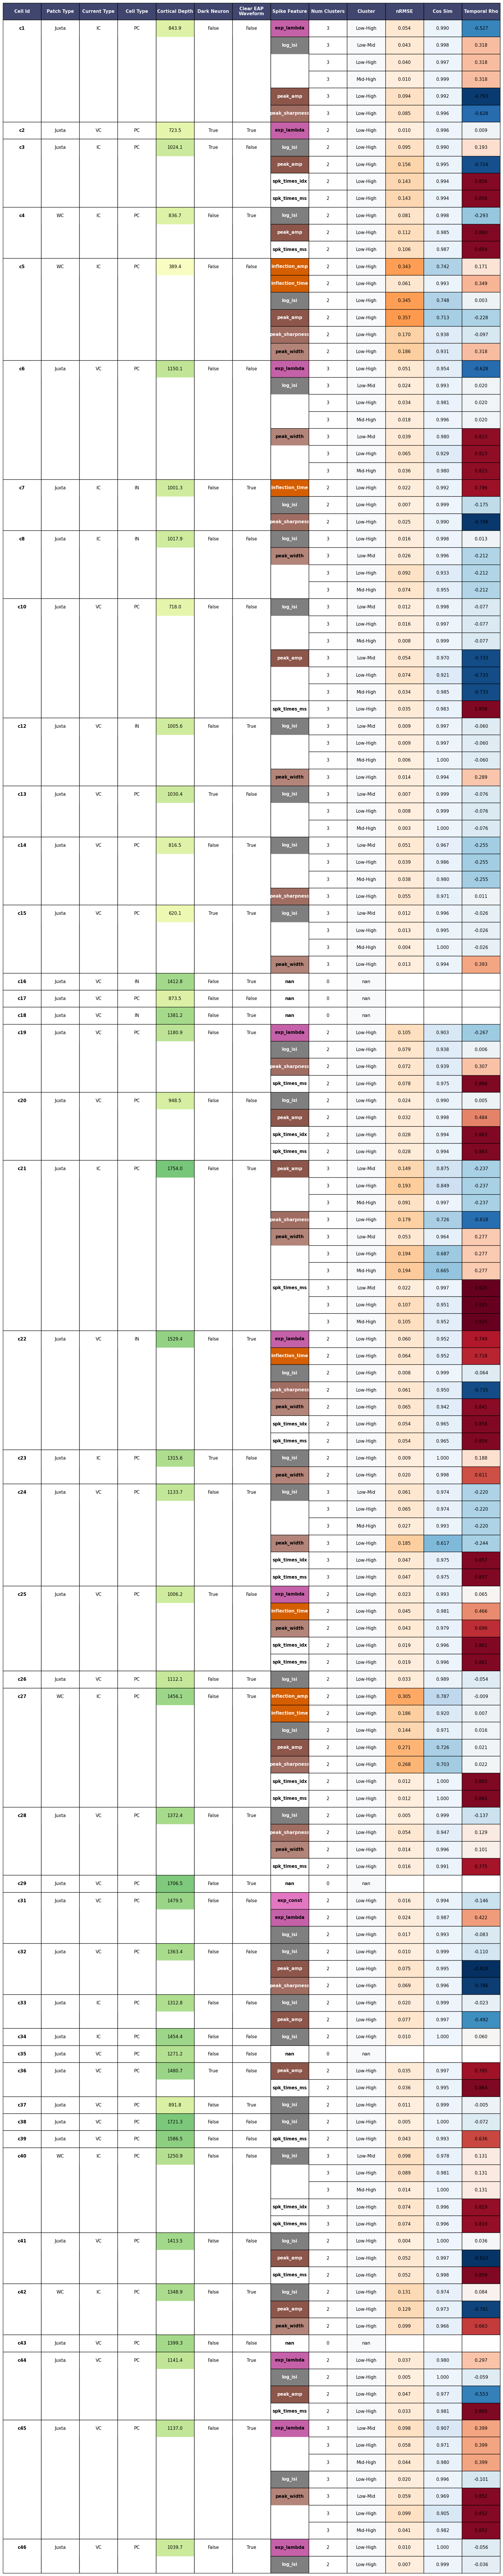

In [6]:

gen_table_fig(df_master)


### Are clustering results driven by biology or recording conditions?

Before interpreting spike waveform clusters as a biological signal, we need to rule out the possibility that clustering quality — or even *which* features cluster — is an artifact of how we recorded. The next three sections cross clustering metrics against recording metadata to test for confounds.

#### A. Does recording metadata predict cluster quality?

Spearman correlations between each metadata variable and the clustering quality metrics: nRMSE (larger = clusters have more different mean waveforms), cos_sim (lower = more different waveform shapes), and num_clusters. A significant association means clustering quality is tied to the recording condition — a potential confound we need to account for before making biological claims.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


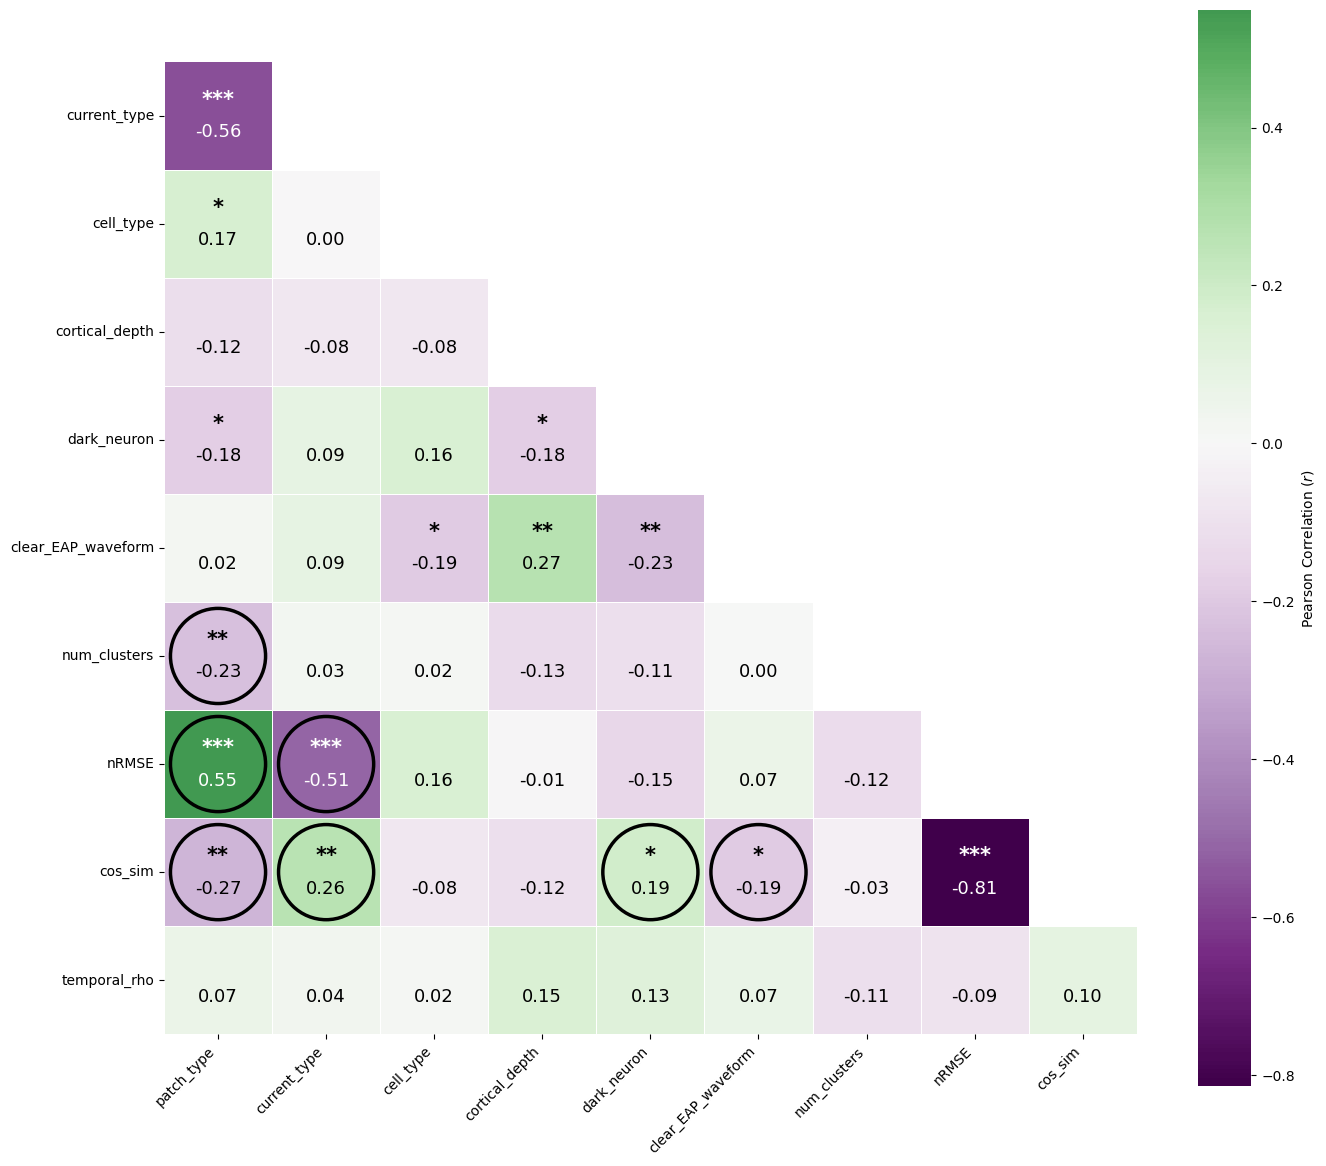

,Metadata,Feature,Pearson $r$,p-value,Significance
0,patch_type,nRMSE,0.549,1.01e-12,***
1,current_type,nRMSE,-0.506,9.63e-11,***
2,patch_type,cos_sim,-0.269,1.11e-03,**
3,current_type,cos_sim,0.263,1.46e-03,**
4,patch_type,num_clusters,-0.230,5.47e-03,**
5,clear_EAP_waveform,cos_sim,-0.195,1.93e-02,*
6,dark_neuron,cos_sim,0.187,2.49e-02,*


In [7]:
sig_meta_clust_feats = analyze_cross_correlations(df_master)
sig_meta_clust_feats

#### Visualizing the significant metadata–cluster pairs

Scatter plots for every pair that came up significant above. We're looking for monotonic trends vs. non-linear patterns, and flagging any combinations that could plausibly confound the biology (e.g., if nRMSE is higher in whole-cell recordings purely because of waveform broadening from the patch).

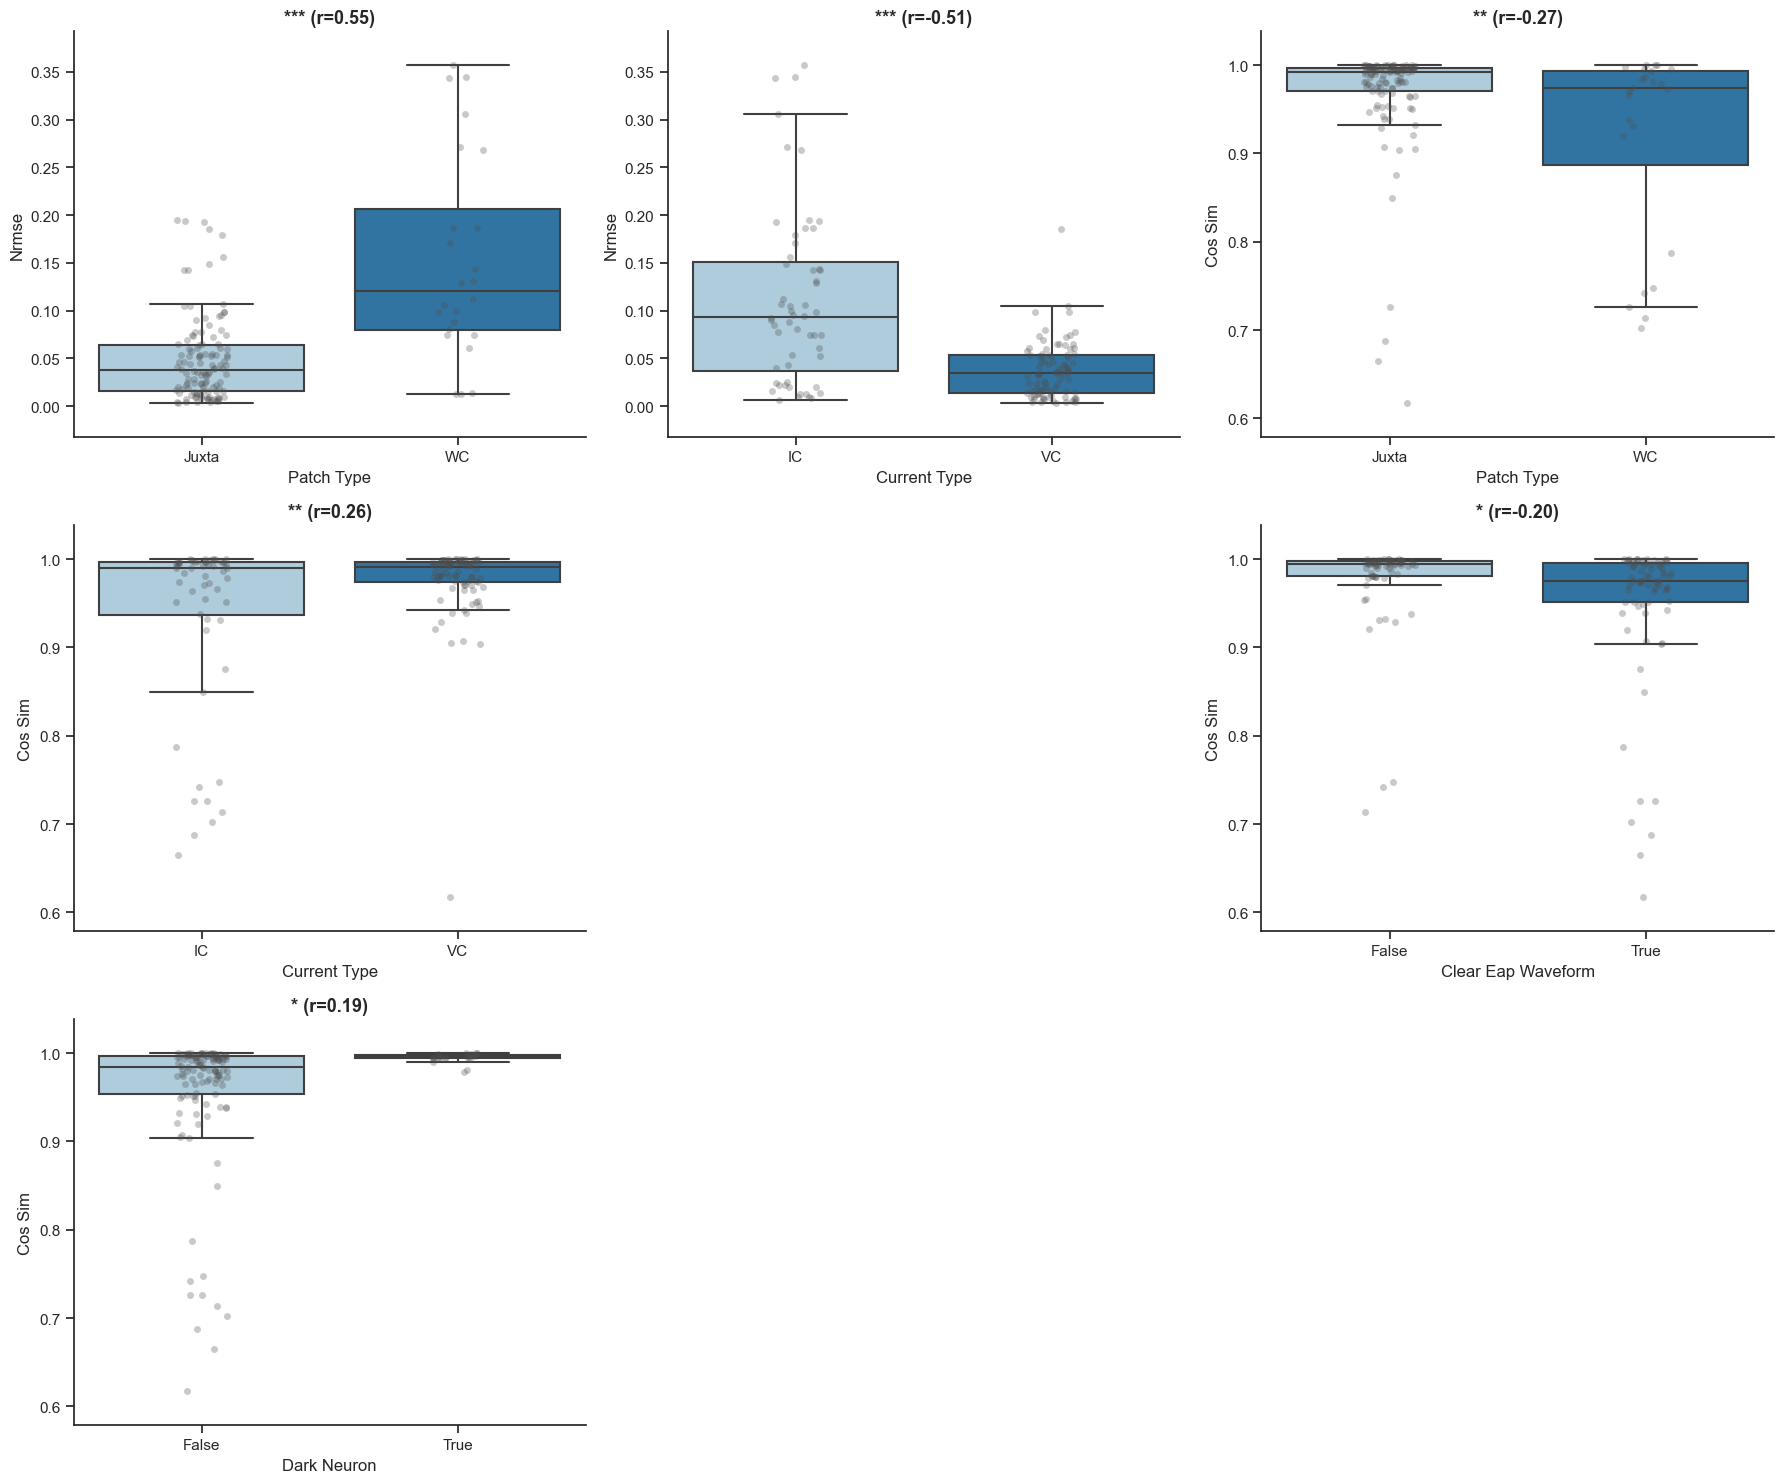

In [8]:
plot_sig_feat_pairs(df_master, sig_meta_clust_feats)



#### B. Which spike features show waveform clustering, and how reliable is it?

Not all spike features cluster equally well or as often. Here we ask: across the full population of cells, which features most commonly produce significant spike clusters, and when they do, how well-separated are those clusters in waveform space?

##### Feature prevalence and cluster quality per spike feature

Aggregated across all cells: how many cells yield a significant cluster for each spike feature, plus mean nRMSE, cos_sim, and temporal_rho. High prevalence + high nRMSE + low cos_sim = a feature that reliably produces well-separated, shape-distinct clusters across the population — the features worth prioritizing for LFP coupling analyses.

In [9]:
#Aggregate cluster metrics and prevalence by spike feature
spk_feat_prevalence = quantify_spk_feature_prevalence(df_master)


In [10]:
spk_feat_prevalence

,spike_feature,n_cells_with_feature,prevalence_pct,num_clusters,cos_sim,nRMSE,temporal_rho
4,log_isi,32,74.418605,2.580000,0.987076,0.036849,-0.026902
9,spk_times_ms,16,37.209302,2.333333,0.984549,0.056211,0.851840
5,peak_amp,14,32.558140,2.388889,0.941217,0.112873,-0.329808
7,peak_width,13,30.232558,2.714286,0.921956,0.076830,0.423504
1,exp_lambda,10,23.255814,2.416667,0.967703,0.047829,0.104982
6,peak_sharpness,10,23.255814,2.300000,0.915454,0.103909,-0.319410
8,spk_times_idx,7,16.279070,2.285714,0.988491,0.053836,0.854192
3,inflection_time,5,11.627907,2.000000,0.967565,0.075660,0.467339
2,inflection_amp,2,4.651163,2.000000,0.764298,0.324293,0.080990
0,exp_const,1,2.325581,2.000000,0.994416,0.015738,-0.145717


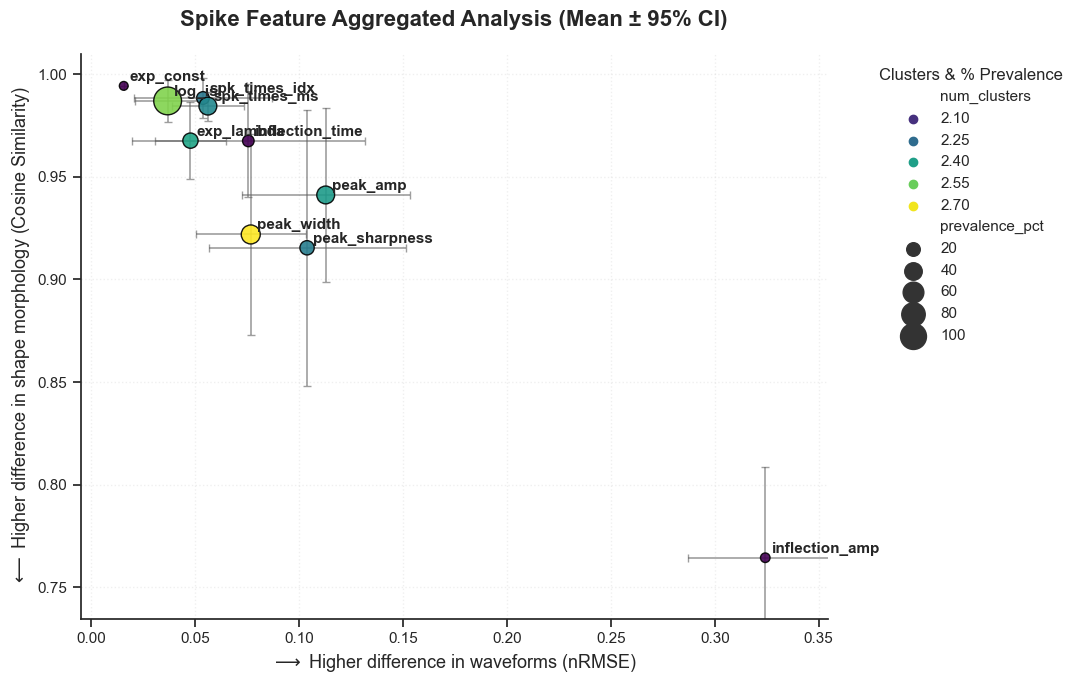

In [11]:
plot_aggregated_spike_feat(df_master)


##### Does metadata predict which spike features cluster?

Chi-square tests (categorical metadata × spike feature) and Spearman correlations (cortical depth × spike feature presence) check whether the features that cluster are skewed toward particular recording conditions. If `peak_width` only clusters in one cell type, that's a biology statement — but if it only clusters in whole-cell recordings, that's a confound.

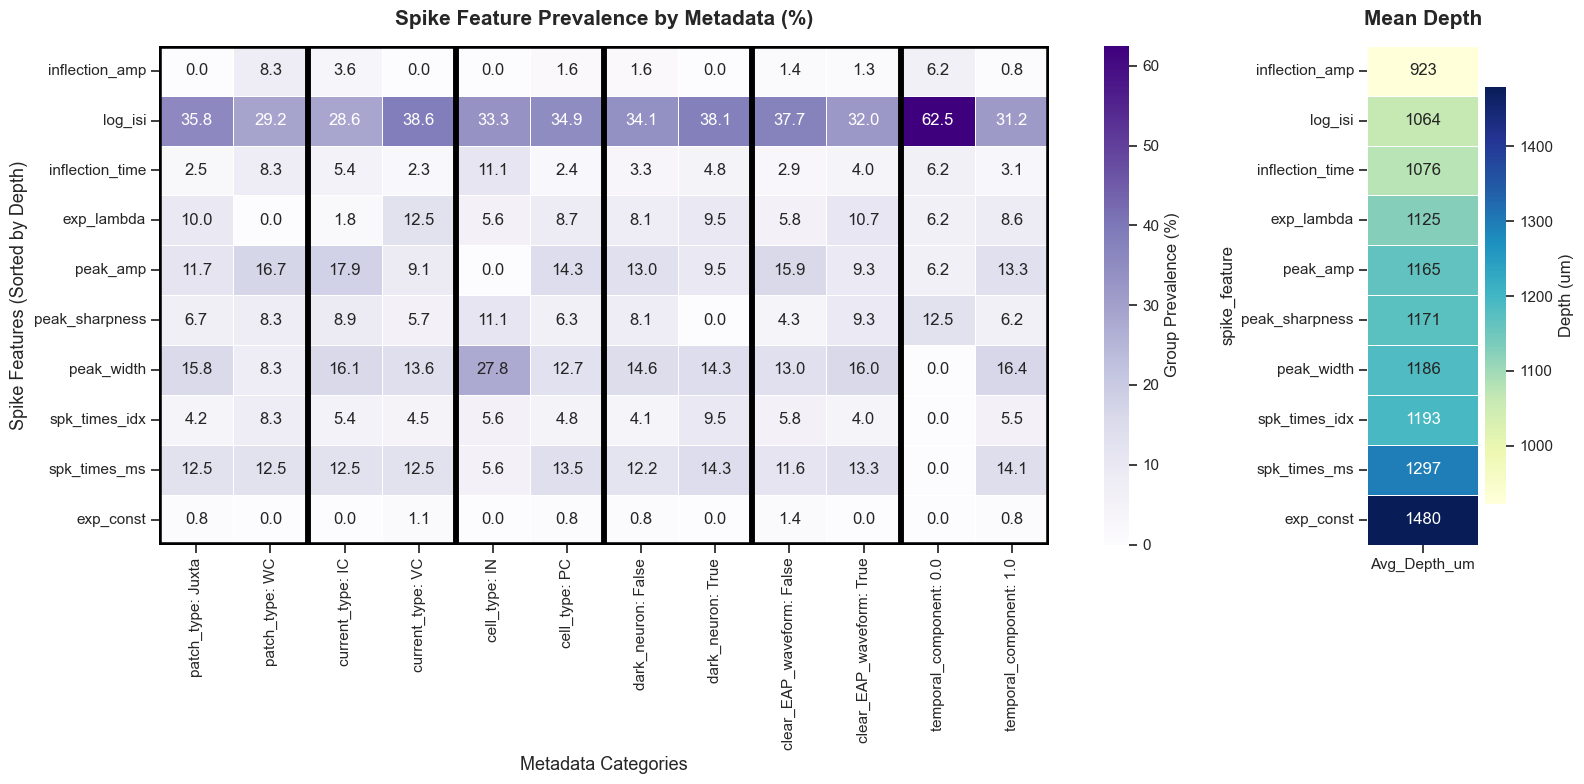

In [12]:
plot_meta_spk_feature_dependency(df_master)

In [13]:

_ = stat_test_metadata_dependency(df_master)

----------------------------------------
METADATA DEPENDENCY ANALYSIS (Chi-Square)
----------------------------------------
patch_type           | p = 5.225e-02 (ns)
current_type         | p = 1.521e-01 (ns)
cell_type            | p = 3.158e-01 (ns)
dark_neuron          | p = 9.242e-01 (ns)
clear_EAP_waveform   | p = 7.738e-01 (ns)
temporal_rho         | p = 1.390e-09 (***)
temporal_p           | p = 4.678e-08 (***)
temporal_component   | p = 9.676e-02 (ns)
----------------------------------------


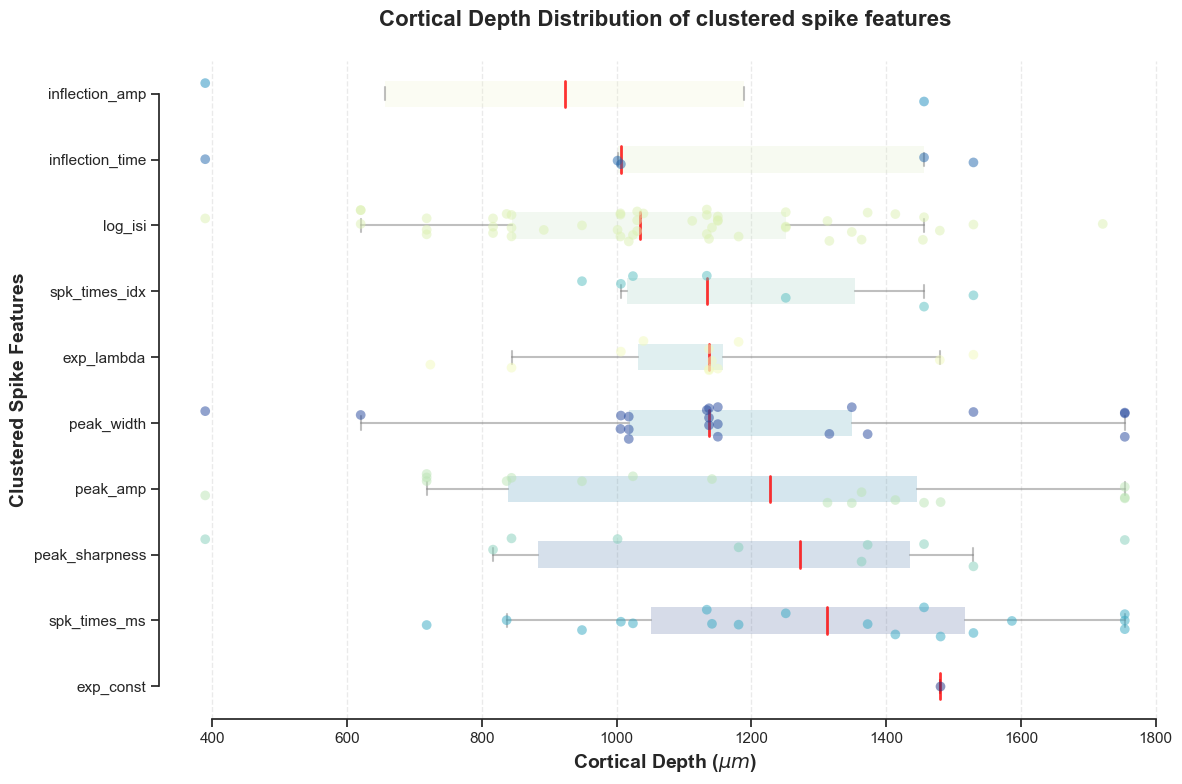

In [14]:
plot_feature_depth_distribution(df_master)

In [15]:
_ =stat_test_depth_stratification(df_master)

----------------------------------------
DEPTH STRATIFICATION ANALYSIS
----------------------------------------
Kruskal-Wallis H-stat: 9.410
p-value: 4.003e-01

No significant depth stratification found.
----------------------------------------


#### C. Which cell × spike feature pairs show the largest waveform differences across clusters?

The top N entries by nRMSE (mean waveform displacement across clusters) and 1 − cos_sim (waveform shape dissimilarity). These are the recordings where cluster identity matters most for spike shape — the strongest candidates for biologically meaningful waveform variability, and the natural starting points for single-cell deep dives.

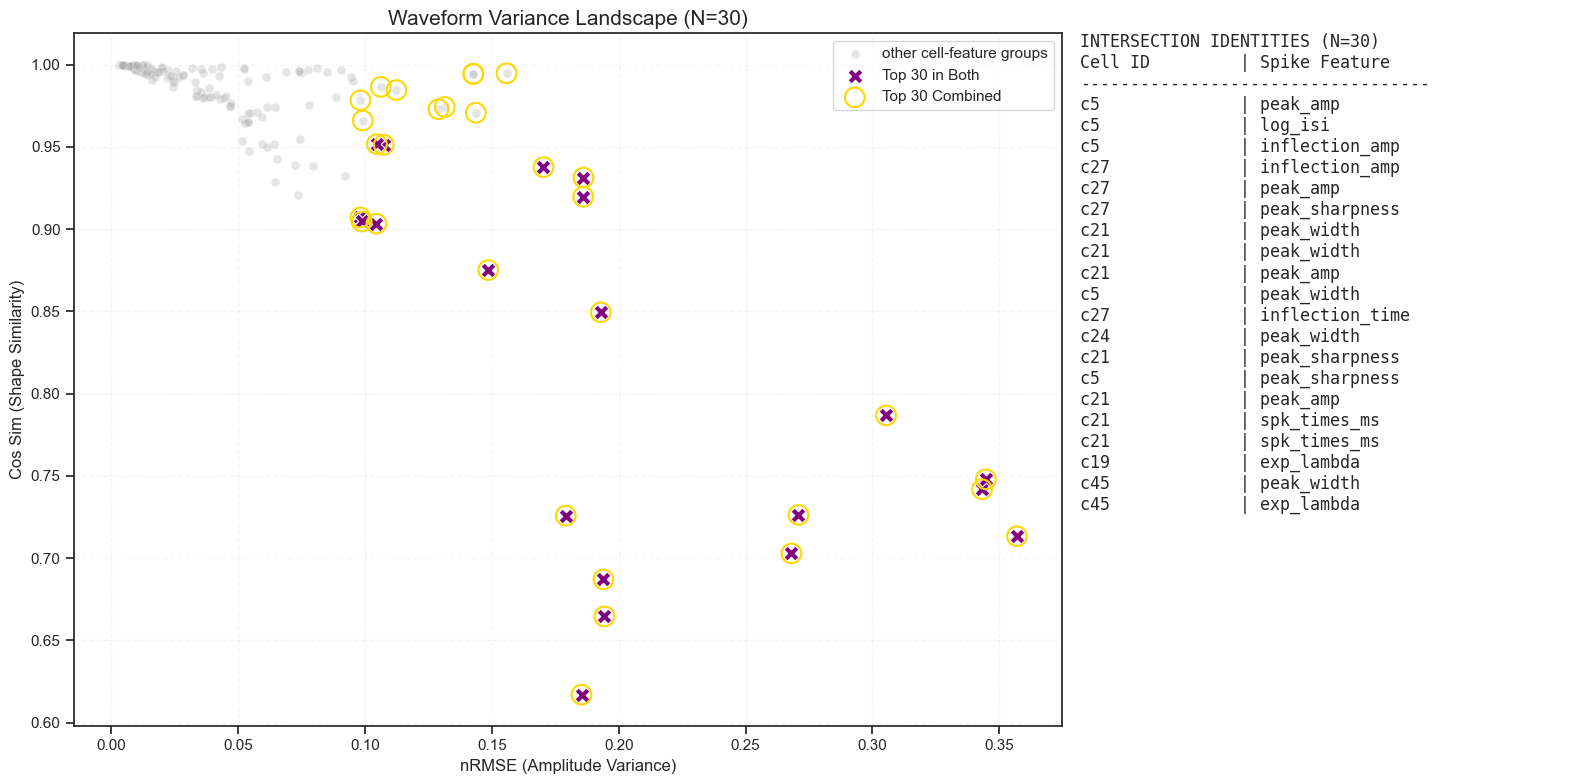

In [16]:
top_var_df = analyze_waveform_variance(df_master, N=30)

In [17]:
top_var_df 

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
16,c5,WC,IC,PC,389.4,False,False,peak_amp,2,Low-High,0.356958,0.713268,-0.227847,8.485455e-112,1.0
19,c5,WC,IC,PC,389.4,False,False,log_isi,2,Low-High,0.344682,0.747875,0.003463,7.361397e-01,0.0
15,c5,WC,IC,PC,389.4,False,False,inflection_amp,2,Low-High,0.343194,0.741832,0.170537,9.724942e-63,1.0
99,c27,WC,IC,PC,1456.1,False,True,inflection_amp,2,Low-High,0.305392,0.786764,-0.008556,5.266647e-01,0.0
100,c27,WC,IC,PC,1456.1,False,True,peak_amp,2,Low-High,0.270852,0.726267,0.020963,1.208560e-01,0.0
101,c27,WC,IC,PC,1456.1,False,True,peak_sharpness,2,Low-High,0.268068,0.702840,0.021714,1.080986e-01,0.0
72,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Mid-High,0.194401,0.664513,0.277442,1.336059e-220,1.0
71,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Low-High,0.193957,0.687091,0.277442,1.336059e-220,1.0
68,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-High,0.192922,0.849435,-0.236587,3.194124e-159,1.0
17,c5,WC,IC,PC,389.4,False,False,peak_width,2,Low-High,0.186114,0.931370,0.318397,3.986261e-222,1.0


#### D. Do spike clusters drift systematically over recording time?

If a cell's cluster identity (Low / Mid / High) correlates with spike time, the neuron's firing is changing over the course of the recording. We measure this via Spearman correlation (`temporal_rho`) between spike time and cluster label, and flag cells where drift is statistically significant.

A significant `temporal_rho` means cluster identity shifts monotonically over the recording (positive ρ = spikes move toward one cluster as time progresses; negative = the reverse). `temporal_component = 1` if that drift is statistically significant (p < 0.05); 0 otherwise. Temporal drift doesn't automatically invalidate clustering, but it means LFP × spike cluster relationships should be interpreted carefully — a pre-spike LFP effect in a drifting cell could partly reflect slow recording-level changes rather than fast network modulation.

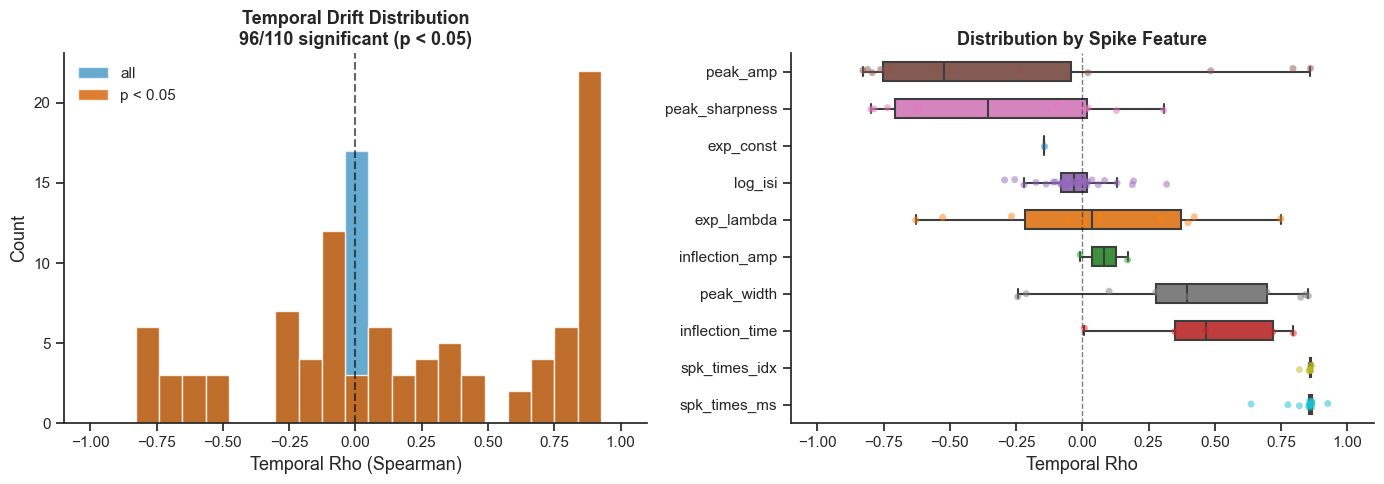


Temporal drift summary (p < 0.05):
  Significant: 96 / 110 cell-feature groups (87.3%)
  Mean |rho|: 0.430

Significant groups:
cell_id   spike_feature  temporal_rho temporal_p
    c32        peak_amp        -0.828    <0.0001
    c41        peak_amp        -0.810    <0.0001
     c7  peak_sharpness        -0.798    <0.0001
     c1        peak_amp        -0.793    <0.0001
    c32  peak_sharpness        -0.786    <0.0001
    c42        peak_amp        -0.761    <0.0001
    c22  peak_sharpness        -0.735    <0.0001
    c10        peak_amp        -0.733    <0.0001
     c3        peak_amp        -0.724    <0.0001
     c6      exp_lambda        -0.628    <0.0001
     c1  peak_sharpness        -0.628    <0.0001
    c21  peak_sharpness        -0.618    <0.0001
    c44        peak_amp        -0.553    <0.0001
     c1      exp_lambda        -0.527    <0.0001
    c33        peak_amp        -0.492    <0.0001
     c4         log_isi        -0.293    <0.0001
    c19      exp_lambda        -0.267 

In [18]:
df_temporal = plot_temporal_structure(df_master)

#### E. Do recording conditions predict temporal drift?

We test whether `temporal_rho` is systematically larger in certain cell types, patch types, or depth ranges. If whole-cell recordings drift more than juxtacellular, that implicates electrode stability over biology. Knowing what drives drift helps us decide when to treat `temporal_component = 1` cells as outliers vs. as genuine slow-modulation biology.

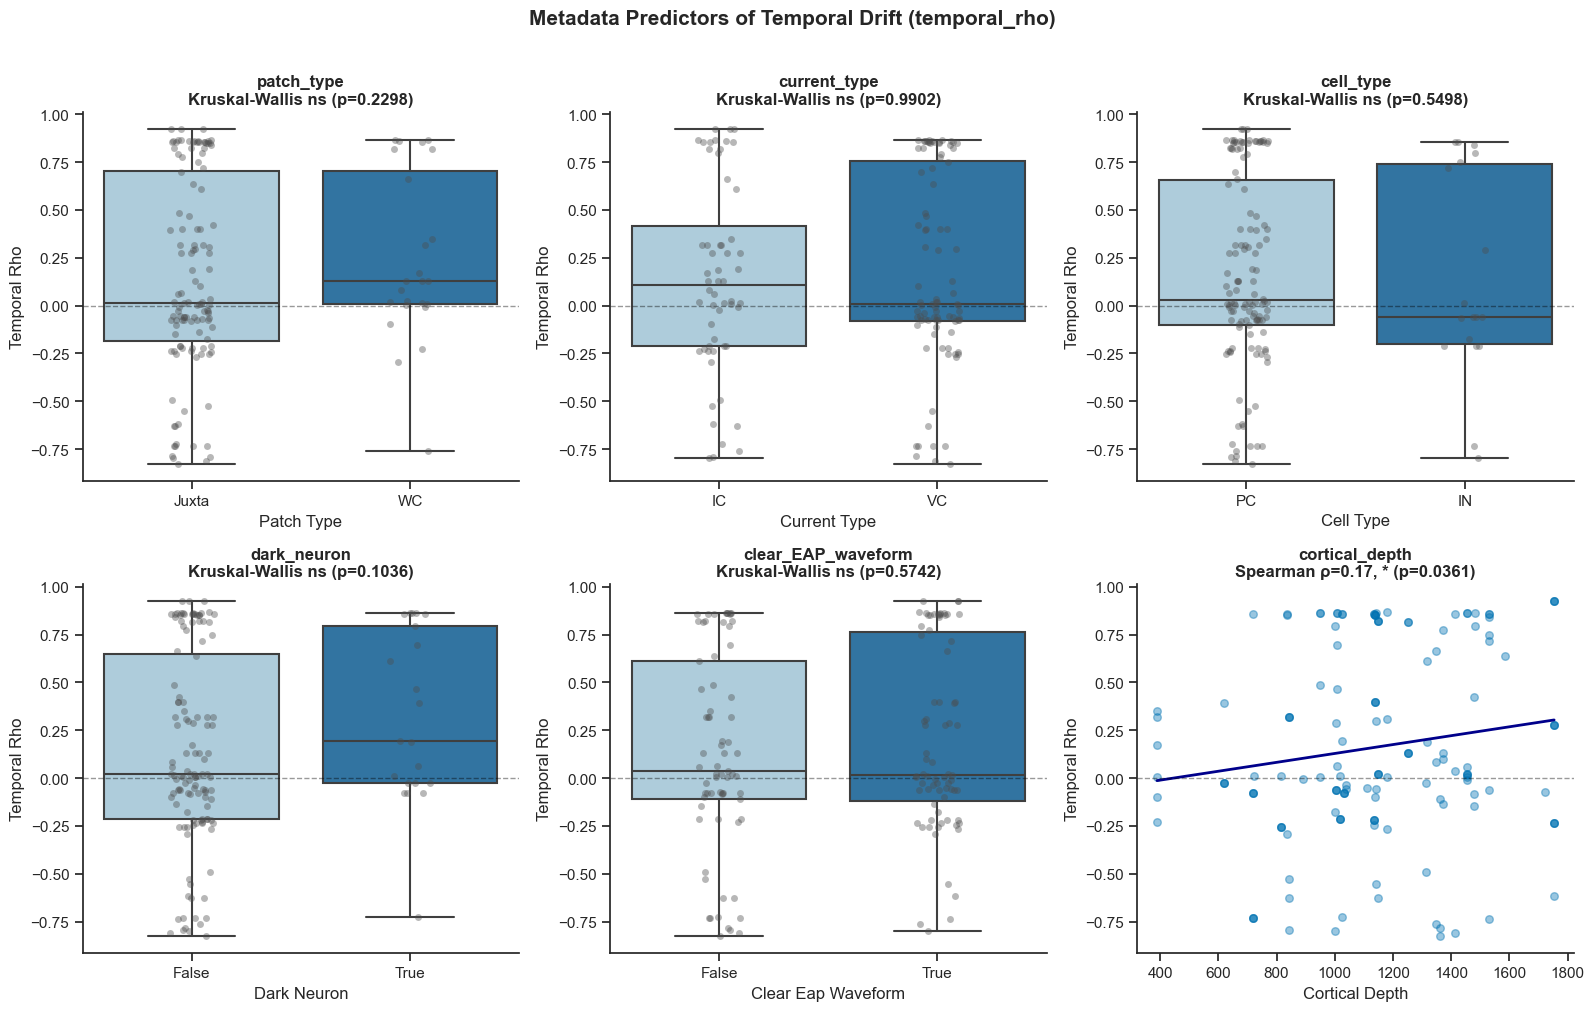


Metadata → temporal_rho test results:
          variable           test  statistic        p sig
    cortical_depth       Spearman      0.175 0.036071   *
       dark_neuron Kruskal-Wallis      2.649 0.103636  ns
        patch_type Kruskal-Wallis      1.442 0.229807  ns
         cell_type Kruskal-Wallis      0.358 0.549792  ns
clear_EAP_waveform Kruskal-Wallis      0.316 0.574183  ns
      current_type Kruskal-Wallis      0.000 0.990190  ns


,variable,test,statistic,p,sig
0,cortical_depth,Spearman,0.175,0.036071,*
1,dark_neuron,Kruskal-Wallis,2.649,0.103636,ns
2,patch_type,Kruskal-Wallis,1.442,0.229807,ns
3,cell_type,Kruskal-Wallis,0.358,0.549792,ns
4,clear_EAP_waveform,Kruskal-Wallis,0.316,0.574183,ns
5,current_type,Kruskal-Wallis,0.000,0.990190,ns


In [19]:
temporal_meta_results = analyze_temporal_metadata_dependency(df_master)
temporal_meta_results

#### F. Does temporal drift correlate with stronger waveform cluster separation?

If cells with more temporal drift also show higher nRMSE or lower cos_sim, it raises the possibility that some of the apparent waveform variability is a slow drift artifact rather than fast modulation by network state. We test this directly — if the correlation is strong, drifting cells should be down-weighted in any population-level effect size claims.

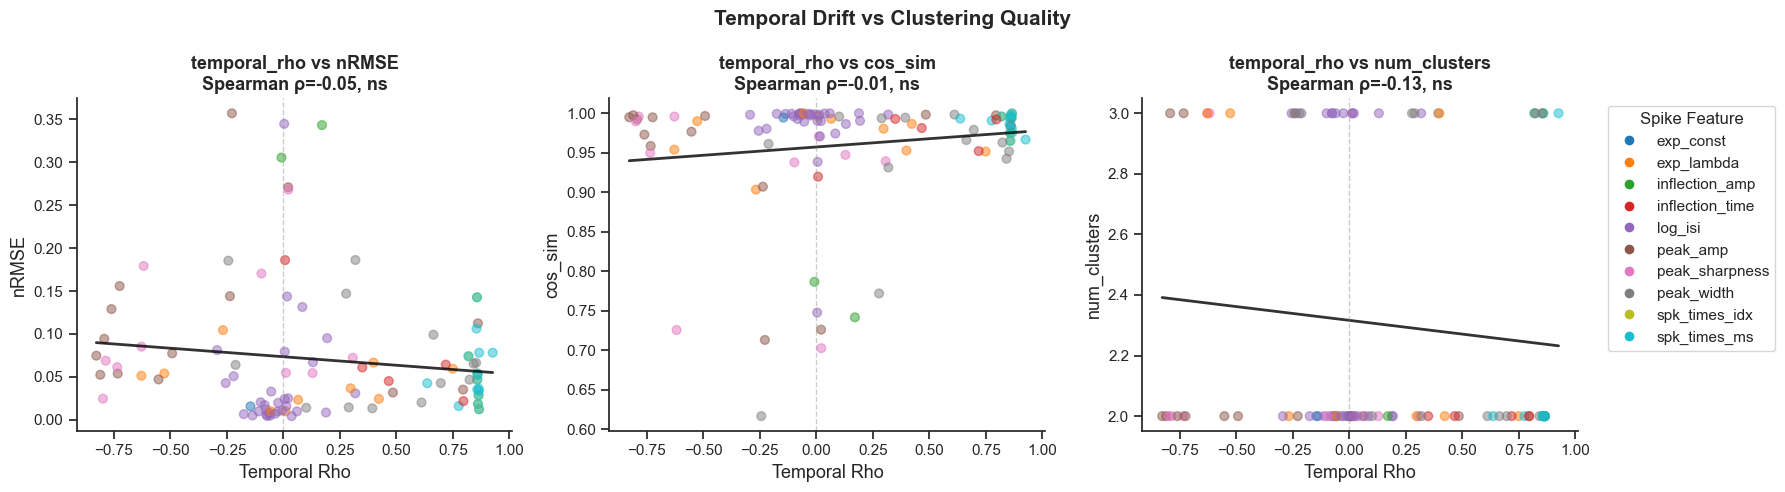

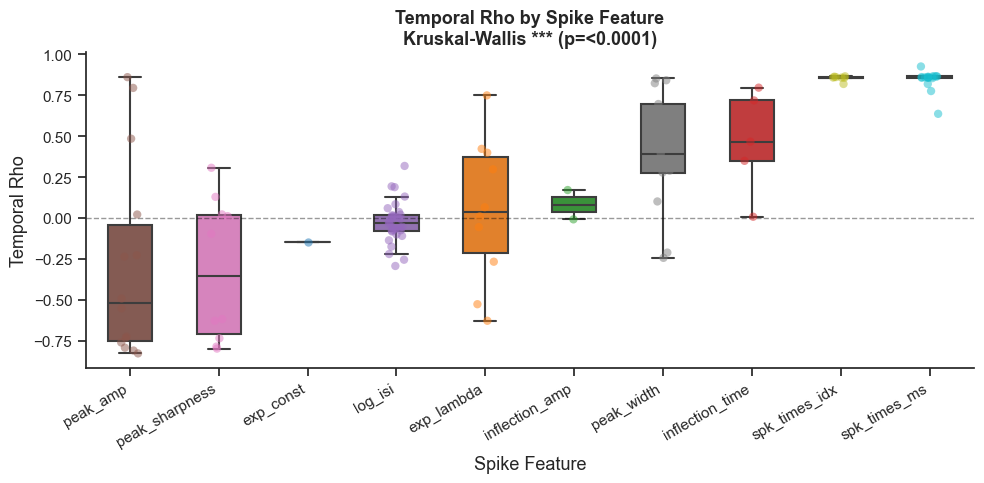

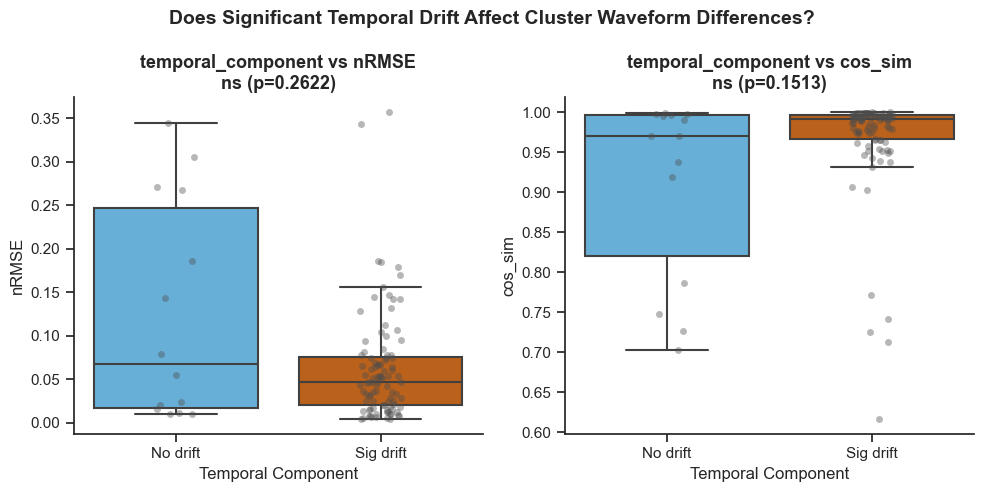


temporal_rho vs clustering metrics (Spearman):
      metric  spearman_rho        p sig
       nRMSE        -0.051 0.595361  ns
     cos_sim        -0.007 0.945365  ns
num_clusters        -0.126 0.190028  ns


,metric,spearman_rho,p,sig
0,nRMSE,-0.051,0.595361,ns
1,cos_sim,-0.007,0.945365,ns
2,num_clusters,-0.126,0.190028,ns


In [20]:
temporal_clust_results = analyze_temporal_clustering_relationship(df_master)
temporal_clust_results

## Summary of Findings

### 1. Clustering Prevalence
- Log ISI: 32/43 cells (74%), mean clusters = 2.58
- Peak amplitude: 14/43 (33%), mean clusters = 2.39
- Peak width: 13/43 (30%), mean clusters = 2.71
- Exp lambda: 10/43 (23%), mean clusters = 2.42
- Peak sharpness: 10/43 (23%), mean clusters = 2.30

### 2. Metadata vs. Cluster Quality
Significant correlations (Pearson r, FDR-corrected):
- Patch type → nRMSE: r = 0.549, p < 0.001 (***)
- Current type → nRMSE: r = −0.506, p < 0.001 (***)
- Patch type → cosine similarity: r = −0.269, p = 0.001 (**)
- Current type → cosine similarity: r = 0.263, p = 0.001 (**)
- Patch type → num clusters: r = −0.230, p = 0.005 (**)
- Clear EAP waveform → cosine similarity: r = −0.195, p = 0.019 (*)
- Dark neuron → cosine similarity: r = 0.187, p = 0.025 (*)

### 3. Metadata vs. Which Feature Clusters (Chi-Square)
- Patch type: p = 0.052 (ns)
- Current type: p = 0.152 (ns)
- Cell type: p = 0.316 (ns)
- Dark neuron: p = 0.924 (ns)
- Clear EAP waveform: p = 0.774 (ns)

### 4. Cortical Depth vs. Clustering
- Kruskal-Wallis H = 9.41, p = 0.40 (ns)

### 5. Temporal Drift
- 96/110 cell-feature groups significant (87.3%), p < 0.05
- Mean |ρ| = 0.430
- Strongest drift: c32 peak_amp (ρ = −0.828), c41 peak_amp (ρ = −0.810), c7 peak_sharpness (ρ = −0.798)

Metadata → temporal rho:
- Cortical depth (Spearman): ρ = 0.175, p = 0.036 (*)
- Dark neuron (Kruskal-Wallis): p = 0.104 (ns)
- Patch type: p = 0.230 (ns)
- Cell type: p = 0.550 (ns)
- Clear EAP waveform: p = 0.574 (ns)
- Current type: p = 0.990 (ns)

Temporal rho vs. cluster quality (Spearman):
- nRMSE: ρ = −0.051, p = 0.595 (ns)
- Cosine similarity: ρ = −0.007, p = 0.945 (ns)
- Num clusters: ρ = −0.126, p = 0.190 (ns)
